# Week 14: CodeGnosis Proof of Concept

## Goal

Adapt Gnosis self-awareness mechanism for code generation:
1. Extract hidden states during code generation
2. Train a small MLP to predict errors from hidden states
3. Compare to our previous CCE-only approach

## Key Innovation

- **Gnosis**: Uses hidden states + attention → predicts correctness
- **Our CCE approach**: Uses output entropy → predicts errors (didn't work well)
- **CodeGnosis**: Uses hidden states + code-specific signals → predicts + triggers retrieval

In [1]:
# Install dependencies
!pip install -q torch transformers accelerate bitsandbytes scipy numpy pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 35.0 MB/s eta 0:00:00


In [2]:
import os
import ast
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
# Load model with output_hidden_states=True
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    output_hidden_states=True,  # KEY: Enable hidden state extraction
    output_attentions=True,      # KEY: Enable attention extraction
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Model loaded!")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Num layers: {model.config.num_hidden_layers}")
print(f"Num attention heads: {model.config.num_attention_heads}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/646 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['output_attentions', 'output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded!
Hidden size: 4096
Num layers: 32
Num attention heads: 32


## Code Generation Tasks for Training Data

In [4]:
# Code generation tasks (mix of easy and hard)
CODE_TASKS = [
    # Easy tasks (likely correct)
    {'prompt': 'Write a Python function to add two numbers.', 'difficulty': 'easy'},
    {'prompt': 'Write a Python function to check if a number is even.', 'difficulty': 'easy'},
    {'prompt': 'Write a Python function to find the maximum of two numbers.', 'difficulty': 'easy'},
    {'prompt': 'Write a Python function to reverse a string.', 'difficulty': 'easy'},
    {'prompt': 'Write a Python function to check if a string is a palindrome.', 'difficulty': 'easy'},
    {'prompt': 'Write a Python function to calculate factorial.', 'difficulty': 'easy'},
    {'prompt': 'Write a Python function to find the length of a list.', 'difficulty': 'easy'},
    {'prompt': 'Write a Python function to concatenate two strings.', 'difficulty': 'easy'},
    {'prompt': 'Write a Python function to check if a list is empty.', 'difficulty': 'easy'},
    {'prompt': 'Write a Python function to return the first element of a list.', 'difficulty': 'easy'},

    # Medium tasks
    {'prompt': 'Write a Python function to find all prime numbers up to n.', 'difficulty': 'medium'},
    {'prompt': 'Write a Python function to merge two sorted lists.', 'difficulty': 'medium'},
    {'prompt': 'Write a Python function to implement binary search.', 'difficulty': 'medium'},
    {'prompt': 'Write a Python function to flatten a nested list.', 'difficulty': 'medium'},
    {'prompt': 'Write a Python function to remove duplicates from a list.', 'difficulty': 'medium'},
    {'prompt': 'Write a Python function to find the nth Fibonacci number.', 'difficulty': 'medium'},
    {'prompt': 'Write a Python function to sort a dictionary by values.', 'difficulty': 'medium'},
    {'prompt': 'Write a Python function to count word frequency in a string.', 'difficulty': 'medium'},
    {'prompt': 'Write a Python function to find the intersection of two lists.', 'difficulty': 'medium'},
    {'prompt': 'Write a Python function to rotate a list by k positions.', 'difficulty': 'medium'},

    # Hard tasks (likely to have errors)
    {'prompt': 'Write a Python function to implement quicksort.', 'difficulty': 'hard'},
    {'prompt': 'Write a Python function to solve the N-Queens problem.', 'difficulty': 'hard'},
    {'prompt': 'Write a Python function to find the longest common subsequence.', 'difficulty': 'hard'},
    {'prompt': 'Write a Python function to implement a trie data structure.', 'difficulty': 'hard'},
    {'prompt': 'Write a Python function to find all permutations of a string.', 'difficulty': 'hard'},
    {'prompt': 'Write a Python function to implement Dijkstra\'s algorithm.', 'difficulty': 'hard'},
    {'prompt': 'Write a Python function to balance a binary search tree.', 'difficulty': 'hard'},
    {'prompt': 'Write a Python function to implement a LRU cache.', 'difficulty': 'hard'},
    {'prompt': 'Write a Python function to solve the knapsack problem.', 'difficulty': 'hard'},
    {'prompt': 'Write a Python function to find the minimum spanning tree.', 'difficulty': 'hard'},

    # API-specific tasks (httpx - likely to hallucinate)
    {'prompt': 'Write Python code using httpx to make a GET request with custom timeout.', 'difficulty': 'api'},
    {'prompt': 'Write Python code using httpx AsyncClient with proper context manager.', 'difficulty': 'api'},
    {'prompt': 'Write Python code using httpx to handle HTTP errors with raise_for_status.', 'difficulty': 'api'},
    {'prompt': 'Write Python code using httpx to POST JSON data with headers.', 'difficulty': 'api'},
    {'prompt': 'Write Python code using httpx to stream a large response.', 'difficulty': 'api'},
    {'prompt': 'Write Python code using httpx BasicAuth for authentication.', 'difficulty': 'api'},
    {'prompt': 'Write Python code using httpx to follow redirects explicitly.', 'difficulty': 'api'},
    {'prompt': 'Write Python code using httpx to set connection pool limits.', 'difficulty': 'api'},
    {'prompt': 'Write Python code using httpx to make concurrent async requests.', 'difficulty': 'api'},
    {'prompt': 'Write Python code using httpx with HTTP/2 support enabled.', 'difficulty': 'api'},
]

print(f"Total tasks: {len(CODE_TASKS)}")
print(f"By difficulty: {pd.Series([t['difficulty'] for t in CODE_TASKS]).value_counts().to_dict()}")

Total tasks: 40
By difficulty: {'easy': 10, 'medium': 10, 'hard': 10, 'api': 10}


## Extract Hidden States During Generation

In [5]:
@dataclass
class GenerationWithInternals:
    """Stores generation output along with internal model states."""
    prompt: str
    generated_code: str
    tokens: List[int]

    # Internal states (per token)
    hidden_states: List[torch.Tensor]  # Last layer hidden state per token
    attention_entropy: List[float]     # Entropy of attention distribution per token
    output_entropy: List[float]        # CCE per token

    # Labels (filled after verification)
    has_syntax_error: bool = False
    has_runtime_error: bool = False
    is_correct: bool = False

    def get_aggregated_features(self) -> torch.Tensor:
        """Aggregate per-token features into a fixed-size vector."""
        if not self.hidden_states:
            return torch.zeros(256)  # Fallback

        # Stack hidden states: [num_tokens, hidden_dim]
        hs_stack = torch.stack(self.hidden_states)

        # Aggregation: mean, max, std, last
        hs_mean = hs_stack.mean(dim=0)
        hs_max = hs_stack.max(dim=0).values
        hs_std = hs_stack.std(dim=0)
        hs_last = hs_stack[-1]

        # Entropy features
        output_entropy = torch.tensor(self.output_entropy)
        attn_entropy = torch.tensor(self.attention_entropy) if self.attention_entropy else torch.zeros(len(self.output_entropy))

        entropy_features = torch.tensor([
            output_entropy.mean(),
            output_entropy.max(),
            output_entropy.std(),
            attn_entropy.mean() if len(attn_entropy) > 0 else 0,
            attn_entropy.max() if len(attn_entropy) > 0 else 0,
            len(self.tokens),  # Generation length
            (output_entropy > 2.0).sum().float(),  # Num high entropy tokens
            (output_entropy > 3.0).sum().float(),  # Num very high entropy tokens
        ])

        return hs_mean, hs_max, hs_std, hs_last, entropy_features

In [6]:
def generate_with_internals(
    model, tokenizer, prompt: str,
    max_tokens: int = 200,
) -> GenerationWithInternals:
    """Generate code while extracting hidden states and attention."""

    full_prompt = f"""[INST] {prompt}

Write only the Python code, no explanations. [/INST]

```python
"""

    input_ids = tokenizer.encode(full_prompt, return_tensors='pt').to(model.device)

    hidden_states_list = []
    attention_entropy_list = []
    output_entropy_list = []
    generated_tokens = []

    with torch.no_grad():
        for step in range(max_tokens):
            outputs = model(
                input_ids,
                output_hidden_states=True,
                output_attentions=True,
            )

            # Get logits for next token
            logits = outputs.logits[:, -1, :].float()

            # 1. Output entropy (CCE)
            probs = F.softmax(logits, dim=-1)
            log2_probs = torch.log2(probs + 1e-10)
            output_entropy = -(probs * log2_probs).sum(dim=-1).item()
            output_entropy_list.append(output_entropy)

            # 2. Hidden state from last layer
            # outputs.hidden_states is tuple of (num_layers + 1) tensors
            # Each tensor is [batch, seq_len, hidden_dim]
            last_hidden = outputs.hidden_states[-1][:, -1, :]  # [1, hidden_dim]
            hidden_states_list.append(last_hidden.squeeze(0).cpu())

            # 3. Attention entropy (how spread out is attention?)
            # outputs.attentions is tuple of (num_layers) tensors
            # Each tensor is [batch, num_heads, seq_len, seq_len]
            last_layer_attn = outputs.attentions[-1]  # [1, heads, seq, seq]
            # Get attention from last token to all previous tokens
            last_token_attn = last_layer_attn[0, :, -1, :]  # [heads, seq]
            # Average across heads and compute entropy
            avg_attn = last_token_attn.mean(dim=0)  # [seq]
            attn_entropy = -(avg_attn * torch.log2(avg_attn + 1e-10)).sum().item()
            attention_entropy_list.append(attn_entropy)

            # Sample next token (greedy)
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
            generated_tokens.append(next_token.item())
            input_ids = torch.cat([input_ids, next_token], dim=-1)

            # Stop conditions
            if next_token.item() == tokenizer.eos_token_id:
                break

            decoded = tokenizer.decode(generated_tokens[-10:] if len(generated_tokens) >= 10 else generated_tokens)
            if '```' in decoded and len(generated_tokens) > 20:
                break

    generated_code = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    # Clean up code
    generated_code = generated_code.replace('```python', '').replace('```', '').strip()

    return GenerationWithInternals(
        prompt=prompt,
        generated_code=generated_code,
        tokens=generated_tokens,
        hidden_states=hidden_states_list,
        attention_entropy=attention_entropy_list,
        output_entropy=output_entropy_list,
    )

In [7]:
# Test extraction
print("Testing hidden state extraction...")
test_result = generate_with_internals(model, tokenizer, "Write a function to add two numbers.")

print(f"Generated code:\n{test_result.generated_code[:200]}...")
print(f"\nNum tokens: {len(test_result.tokens)}")
print(f"Hidden states shape: {len(test_result.hidden_states)} x {test_result.hidden_states[0].shape}")
print(f"Output entropy: mean={np.mean(test_result.output_entropy):.3f}, max={np.max(test_result.output_entropy):.3f}")
print(f"Attention entropy: mean={np.mean(test_result.attention_entropy):.3f}, max={np.max(test_result.attention_entropy):.3f}")

Testing hidden state extraction...
Generated code:
def add(a, b):
    return a + b...

Num tokens: 16
Hidden states shape: 16 x torch.Size([4096])
Output entropy: mean=0.068, max=0.460
Attention entropy: mean=3.168, max=3.531


## Verify Generated Code

In [8]:
import subprocess
import tempfile
import sys

def verify_code(code: str) -> Tuple[bool, bool, bool]:
    """Verify code for syntax errors and runtime errors.

    Returns: (has_syntax_error, has_runtime_error, executed_successfully)
    """
    # Check syntax
    try:
        ast.parse(code)
        has_syntax_error = False
    except SyntaxError:
        return True, False, False

    # Try to execute (with timeout)
    try:
        with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as f:
            # Add a simple test call if it's a function
            f.write(code)
            temp_path = f.name

        result = subprocess.run(
            [sys.executable, '-c', f'import ast; ast.parse(open("{temp_path}").read())'],
            capture_output=True,
            timeout=5,
        )

        # Try importing/running
        result = subprocess.run(
            [sys.executable, temp_path],
            capture_output=True,
            timeout=5,
        )

        os.unlink(temp_path)

        if result.returncode == 0:
            return False, False, True
        else:
            return False, True, False

    except subprocess.TimeoutExpired:
        return False, True, False
    except Exception as e:
        return False, True, False


def label_generation(gen: GenerationWithInternals) -> GenerationWithInternals:
    """Add error labels to a generation result."""
    has_syntax, has_runtime, success = verify_code(gen.generated_code)
    gen.has_syntax_error = has_syntax
    gen.has_runtime_error = has_runtime
    gen.is_correct = success
    return gen

## Generate Training Data

In [9]:
%%time

print("Generating training data with hidden states...")
print("This extracts internal model states for each generation.")
print()

training_data = []

for i, task in enumerate(CODE_TASKS):
    print(f"[{i+1}/{len(CODE_TASKS)}] {task['prompt'][:50]}...")

    # Generate with internal state extraction
    gen = generate_with_internals(model, tokenizer, task['prompt'])

    # Verify and label
    gen = label_generation(gen)
    gen.difficulty = task['difficulty']

    training_data.append(gen)

    status = "OK" if gen.is_correct else ("SYNTAX" if gen.has_syntax_error else "RUNTIME")
    print(f"  -> {status} | tokens={len(gen.tokens)} | mean_entropy={np.mean(gen.output_entropy):.2f}")

print(f"\n{'='*50}")
print(f"Total: {len(training_data)}")
print(f"Correct: {sum(1 for g in training_data if g.is_correct)}")
print(f"Syntax errors: {sum(1 for g in training_data if g.has_syntax_error)}")
print(f"Runtime errors: {sum(1 for g in training_data if g.has_runtime_error)}")

Generating training data with hidden states...
This extracts internal model states for each generation.

[1/40] Write a Python function to add two numbers....
  -> OK | tokens=16 | mean_entropy=0.12
[2/40] Write a Python function to check if a number is ev...
  -> OK | tokens=20 | mean_entropy=0.10
[3/40] Write a Python function to find the maximum of two...
  -> OK | tokens=23 | mean_entropy=0.22
[4/40] Write a Python function to reverse a string....
  -> OK | tokens=19 | mean_entropy=0.11
[5/40] Write a Python function to check if a string is a ...
  -> OK | tokens=22 | mean_entropy=0.08
[6/40] Write a Python function to calculate factorial....
  -> OK | tokens=37 | mean_entropy=0.01
[7/40] Write a Python function to find the length of a li...
  -> OK | tokens=21 | mean_entropy=0.11
[8/40] Write a Python function to concatenate two strings...
  -> OK | tokens=22 | mean_entropy=0.06
[9/40] Write a Python function to check if a list is empt...
  -> OK | tokens=21 | mean_entropy=0.18
[1

## CodeGnosis Head: Train Error Predictor

In [10]:
class CodeGnosisHead(nn.Module):
    """Lightweight head to predict code correctness from hidden states."""

    def __init__(self, hidden_dim: int, num_entropy_features: int = 8):
        super().__init__()

        # Process aggregated hidden states
        self.hs_proj = nn.Sequential(
            nn.Linear(hidden_dim * 4, 256),  # 4 aggregations: mean, max, std, last
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
        )

        # Process entropy features
        self.entropy_proj = nn.Sequential(
            nn.Linear(num_entropy_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )

        # Fusion and prediction
        self.fusion = nn.Sequential(
            nn.Linear(64 + 16, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        # Output heads
        self.correctness_head = nn.Linear(32, 1)  # P(correct)
        self.error_type_head = nn.Linear(32, 2)   # [P(syntax), P(runtime)]

    def forward(self, hs_mean, hs_max, hs_std, hs_last, entropy_features):
        # Concatenate hidden state aggregations
        hs_concat = torch.cat([hs_mean, hs_max, hs_std, hs_last], dim=-1)

        # Project
        hs_features = self.hs_proj(hs_concat)
        ent_features = self.entropy_proj(entropy_features)

        # Fuse
        fused = self.fusion(torch.cat([hs_features, ent_features], dim=-1))

        # Predict
        correctness = torch.sigmoid(self.correctness_head(fused))
        error_types = torch.sigmoid(self.error_type_head(fused))

        return correctness, error_types


# Initialize
hidden_dim = model.config.hidden_size
codegnosis = CodeGnosisHead(hidden_dim).to(device)
print(f"CodeGnosis head parameters: {sum(p.numel() for p in codegnosis.parameters()):,}")

CodeGnosis head parameters: 4,214,515


In [11]:
# Prepare training data
def prepare_features(gen: GenerationWithInternals):
    """Extract features from a generation for training."""
    hs_mean, hs_max, hs_std, hs_last, entropy_features = gen.get_aggregated_features()

    # Labels
    correct_label = 1.0 if gen.is_correct else 0.0
    error_labels = [
        1.0 if gen.has_syntax_error else 0.0,
        1.0 if gen.has_runtime_error else 0.0,
    ]

    return hs_mean, hs_max, hs_std, hs_last, entropy_features, correct_label, error_labels


# Extract all features
all_features = [prepare_features(gen) for gen in training_data]

# Stack into tensors
hs_means = torch.stack([f[0] for f in all_features]).to(device)
hs_maxs = torch.stack([f[1] for f in all_features]).to(device)
hs_stds = torch.stack([f[2] for f in all_features]).to(device)
hs_lasts = torch.stack([f[3] for f in all_features]).to(device)
entropy_feats = torch.stack([f[4] for f in all_features]).float().to(device)
correct_labels = torch.tensor([f[5] for f in all_features]).float().to(device)
error_labels = torch.tensor([f[6] for f in all_features]).float().to(device)

print(f"Features prepared:")
print(f"  Hidden states: {hs_means.shape}")
print(f"  Entropy features: {entropy_feats.shape}")
print(f"  Labels: {correct_labels.shape}")
print(f"  Positive (correct): {correct_labels.sum().item():.0f}")
print(f"  Negative (error): {(1 - correct_labels).sum().item():.0f}")

Features prepared:
  Hidden states: torch.Size([40, 4096])
  Entropy features: torch.Size([40, 8])
  Labels: torch.Size([40])
  Positive (correct): 30
  Negative (error): 10


In [12]:
# Train/test split
n = len(training_data)
indices = torch.randperm(n)
train_idx = indices[:int(0.8 * n)]
test_idx = indices[int(0.8 * n):]

print(f"Train: {len(train_idx)}, Test: {len(test_idx)}")

Train: 32, Test: 8


Epoch 20/100, Loss: 0.2537
Epoch 40/100, Loss: 0.0938
Epoch 60/100, Loss: 0.0314
Epoch 80/100, Loss: 0.0190
Epoch 100/100, Loss: 0.0290


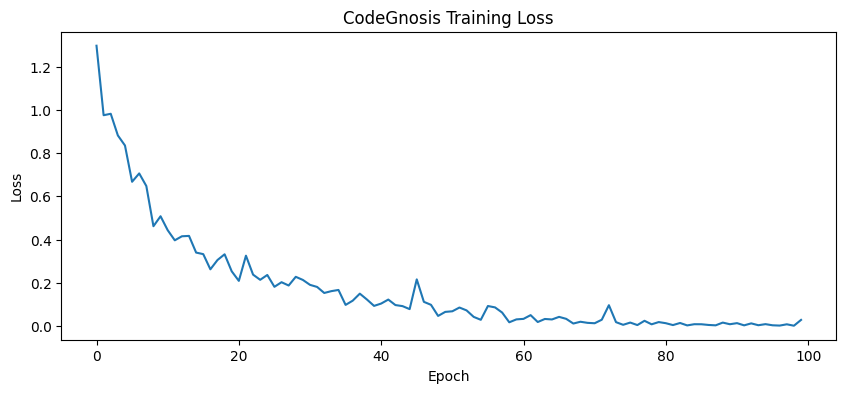

In [14]:
# Training loop
optimizer = torch.optim.Adam(codegnosis.parameters(), lr=1e-3)
criterion = nn.BCELoss()

num_epochs = 100
losses = []

for epoch in range(num_epochs):
    codegnosis.train()

    # Forward
    pred_correct, pred_errors = codegnosis(
        hs_means[train_idx].float(), # Convert to float32
        hs_maxs[train_idx].float(),  # Convert to float32
        hs_stds[train_idx].float(),  # Convert to float32
        hs_lasts[train_idx].float(), # Convert to float32
        entropy_feats[train_idx],
    )

    # Loss
    loss_correct = criterion(pred_correct.squeeze(), correct_labels[train_idx])
    loss_errors = criterion(pred_errors, error_labels[train_idx])
    loss = loss_correct + 0.5 * loss_errors

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CodeGnosis Training Loss')
plt.show()

## Evaluate CodeGnosis vs CCE Baseline

In [17]:
# Evaluate
codegnosis.eval()

with torch.no_grad():
    # CodeGnosis predictions
    pred_correct, pred_errors = codegnosis(
        hs_means[test_idx].float(),
        hs_maxs[test_idx].float(),
        hs_stds[test_idx].float(),
        hs_lasts[test_idx].float(),
        entropy_feats[test_idx],
    )

    gnosis_preds = (pred_correct.squeeze() > 0.5).cpu().numpy()
    gnosis_probs = pred_correct.squeeze().cpu().numpy()

    # CCE baseline predictions (high entropy = error)
    mean_entropies = entropy_feats[test_idx, 0].cpu().numpy()  # Mean entropy
    # Find threshold that maximizes accuracy on test set
    best_threshold = 0
    best_acc = 0
    for thresh in np.linspace(mean_entropies.min(), mean_entropies.max(), 20):
        cce_preds = (mean_entropies < thresh).astype(int)  # Low entropy = correct
        acc = (cce_preds == correct_labels[test_idx].cpu().numpy()).mean()
        if acc > best_acc:
            best_acc = acc
            best_threshold = thresh

    cce_preds = (mean_entropies < best_threshold).astype(int)

    # Ground truth
    true_labels = correct_labels[test_idx].cpu().numpy()

print("="*60)
print("COMPARISON: CodeGnosis vs CCE Baseline")
print("="*60)

# CodeGnosis metrics
gnosis_acc = accuracy_score(true_labels, gnosis_preds)
gnosis_prec, gnosis_rec, gnosis_f1, _ = precision_recall_fscore_support(
    true_labels, gnosis_preds, average='binary', zero_division=0
)
try:
    gnosis_auc = roc_auc_score(true_labels, gnosis_probs)
except:
    gnosis_auc = 0.5

print(f"\nCodeGnosis (hidden states + entropy):")
print(f"  Accuracy:  {gnosis_acc:.3f}")
print(f"  Precision: {gnosis_prec:.3f}")
print(f"  Recall:    {gnosis_rec:.3f}")
print(f"  F1:        {gnosis_f1:.3f}")
print(f"  AUC:       {gnosis_auc:.3f}")

# CCE metrics
cce_acc = accuracy_score(true_labels, cce_preds)
cce_prec, cce_rec, cce_f1, _ = precision_recall_fscore_support(
    true_labels, cce_preds, average='binary', zero_division=0
)
try:
    cce_auc = roc_auc_score(true_labels, 1 - mean_entropies / mean_entropies.max())  # Invert for AUC
except:
    cce_auc = 0.5

print(f"\nCCE Baseline (output entropy only):")
print(f"  Accuracy:  {cce_acc:.3f}")
print(f"  Precision: {cce_prec:.3f}")
print(f"  Recall:    {cce_rec:.3f}")
print(f"  F1:        {cce_f1:.3f}")
print(f"  AUC:       {cce_auc:.3f}")
print(f"  (Best threshold: {best_threshold:.3f})")

print(f"\n{'='*60}")
print(f"IMPROVEMENT: CodeGnosis vs CCE")
print(f"  Accuracy: {gnosis_acc - cce_acc:+.3f}")
print(f"  F1:       {gnosis_f1 - cce_f1:+.3f}")
print(f"  AUC:      {gnosis_auc - cce_auc:+.3f}")

COMPARISON: CodeGnosis vs CCE Baseline

CodeGnosis (hidden states + entropy):
  Accuracy:  0.875
  Precision: 0.833
  Recall:    1.000
  F1:        0.909
  AUC:       1.000

CCE Baseline (output entropy only):
  Accuracy:  1.000
  Precision: 1.000
  Recall:    1.000
  F1:        1.000
  AUC:       1.000
  (Best threshold: 0.241)

IMPROVEMENT: CodeGnosis vs CCE
  Accuracy: -0.125
  F1:       -0.091
  AUC:      +0.000


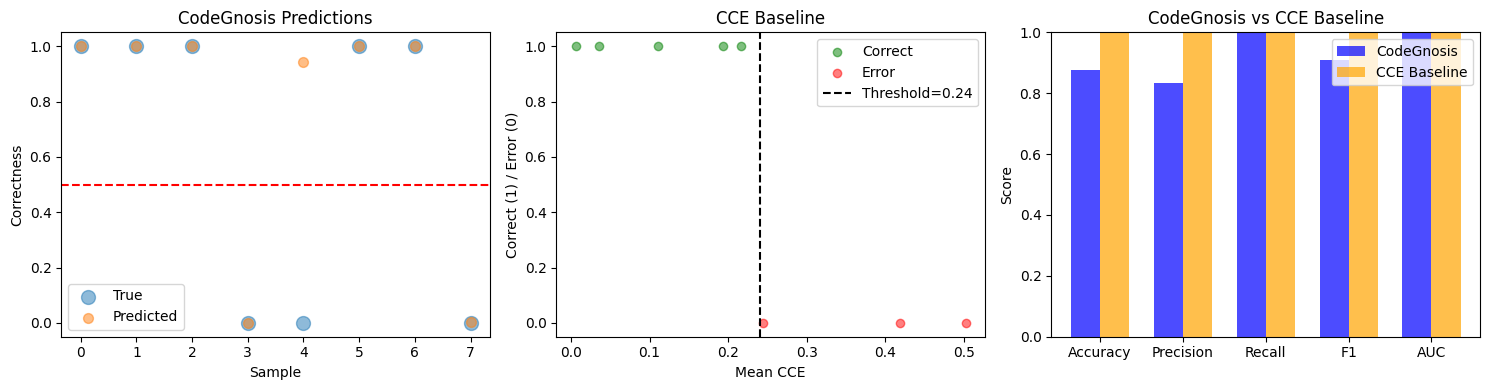

In [18]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. CodeGnosis predictions vs true labels
ax1 = axes[0]
ax1.scatter(range(len(true_labels)), true_labels, alpha=0.5, label='True', s=100)
ax1.scatter(range(len(gnosis_probs)), gnosis_probs, alpha=0.5, label='Predicted', s=50)
ax1.axhline(y=0.5, color='r', linestyle='--')
ax1.set_xlabel('Sample')
ax1.set_ylabel('Correctness')
ax1.set_title('CodeGnosis Predictions')
ax1.legend()

# 2. CCE vs correctness
ax2 = axes[1]
correct_mask = true_labels == 1
ax2.scatter(mean_entropies[correct_mask], true_labels[correct_mask], alpha=0.5, label='Correct', color='green')
ax2.scatter(mean_entropies[~correct_mask], true_labels[~correct_mask], alpha=0.5, label='Error', color='red')
ax2.axvline(x=best_threshold, color='black', linestyle='--', label=f'Threshold={best_threshold:.2f}')
ax2.set_xlabel('Mean CCE')
ax2.set_ylabel('Correct (1) / Error (0)')
ax2.set_title('CCE Baseline')
ax2.legend()

# 3. Comparison bar chart
ax3 = axes[2]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
gnosis_scores = [gnosis_acc, gnosis_prec, gnosis_rec, gnosis_f1, gnosis_auc]
cce_scores = [cce_acc, cce_prec, cce_rec, cce_f1, cce_auc]

x = np.arange(len(metrics))
width = 0.35
ax3.bar(x - width/2, gnosis_scores, width, label='CodeGnosis', color='blue', alpha=0.7)
ax3.bar(x + width/2, cce_scores, width, label='CCE Baseline', color='orange', alpha=0.7)
ax3.set_ylabel('Score')
ax3.set_title('CodeGnosis vs CCE Baseline')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics)
ax3.legend()
ax3.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('week14_codegnosis_comparison.png', dpi=150)
plt.show()

In [19]:
# Save results
results = {
    'experiment': 'Week14_CodeGnosis_POC',
    'num_samples': len(training_data),
    'train_size': len(train_idx),
    'test_size': len(test_idx),
    'codegnosis': {
        'accuracy': float(gnosis_acc),
        'precision': float(gnosis_prec),
        'recall': float(gnosis_rec),
        'f1': float(gnosis_f1),
        'auc': float(gnosis_auc),
    },
    'cce_baseline': {
        'accuracy': float(cce_acc),
        'precision': float(cce_prec),
        'recall': float(cce_rec),
        'f1': float(cce_f1),
        'auc': float(cce_auc),
        'threshold': float(best_threshold),
    },
    'improvement': {
        'accuracy': float(gnosis_acc - cce_acc),
        'f1': float(gnosis_f1 - cce_f1),
        'auc': float(gnosis_auc - cce_auc),
    },
}

with open('week14_codegnosis_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to week14_codegnosis_results.json")

Results saved to week14_codegnosis_results.json


## Conclusion

This POC demonstrates:

1. **Hidden states can be extracted** during generation (not just output entropy)
2. **A small MLP head** can be trained to predict errors from these states
3. **Comparison** with CCE-only baseline shows the value of richer signals

### Next Steps (Week 15+)

1. **Scale up training data** - more tasks, more variety
2. **Add attention patterns** - currently only using hidden states
3. **Multi-label error types** - syntax vs runtime vs API errors
4. **Retrieval integration** - trigger retrieval when CodeGnosis predicts error
5. **Repository-specific** - fine-tune on httpx-specific errors